# BaySpec OCI-F Lake Processor — **Silver Lake, SP2026** (10-bit)

Local VS Code pipeline for BaySpec OCI-F pushbroom hyperspectral drone data.
Pick inputs with native **Finder** dialogs — no Colab, no hardcoded paths.

**Handles 8-bit *and* 10/16-bit captures automatically** (bit depth is detected from
the raw file size). For the SP2026 Silver Lake config the data is 10-bit stored in a
16-bit container, and the white reference is **not** saturated — so reflectance is
quantitative (`SAT_BIAS = 1.0`, no fudge factor).

**Pipeline:** XML calibration → load + bin to cube → reflectance → water-quality
indices (NDCI, red-edge, chl-a) → save combined `.npz` → *(optional)* georeferenced
glint-free smoothed mosaic (true-color + NDCI GeoTIFFs for QGIS).

**You will be prompted to select (in order):** OCI-F XML · Dark frame · White frame ·
lake frames (Cmd-click several) · *(optional)* the GPS flight-log CSV.

**Requires:** numpy, scipy, matplotlib, rasterio (all in the anaconda env).


## 1. Imports + Finder picker

In [8]:
%matplotlib inline
import numpy as np, os, json, datetime, csv
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

# native macOS Finder dialog
import tkinter as tk
from tkinter import filedialog

def pick(title, multiple=False, directory=False, filetypes=(('All files', '*.*'),), initialdir=None):
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    try:
        if directory:  return filedialog.askdirectory(title=title, initialdir=initialdir)
        if multiple:   return list(filedialog.askopenfilenames(title=title, filetypes=list(filetypes), initialdir=initialdir))
        return filedialog.askopenfilename(title=title, filetypes=list(filetypes), initialdir=initialdir)
    finally:
        root.update(); root.destroy()

plt.rcParams['figure.dpi'] = 110
print('Ready — pick inputs with Finder in the next sections.')

Ready — pick inputs with Finder in the next sections.


## 2. Select the OCI-F XML calibration file

In [9]:
XML_PATH = pick('Select the OCI-F XML calibration file',
                filetypes=[('XML', '*.xml'), ('All files', '*.*')])
if not XML_PATH:
    raise FileNotFoundError('No XML selected.')
print('XML:', XML_PATH)

XML: C:/Users/daven/Downloads/REU Spring Lake/Spring Lake/09-56-10RES1280_EXP0038_GAN0010_BIT08_2EXP0000_GAN0010_RES1280_BIT08/OCI-F-V2490276.xml


## 3. Parse XML → sensor config + wavelength axis

In [10]:
def parse_ocif_xml(p):
    s = ET.parse(p).getroot().find('sensor')
    g = lambda t: s.find(t).text
    cfg = dict(width=int(g('width')), height=int(g('height')),
               linesperband=int(g('linesperband')), bandpixels=int(g('bandpixels')),
               c0=float(g('c0')), c1=float(g('c1')), c2=float(g('c2')))
    cfg['n_bands'] = cfg['height'] // cfg['linesperband']
    cfg['n_spatial'] = cfg['width'] // cfg['bandpixels']
    by = np.arange(cfg['n_bands']) * cfg['linesperband'] + cfg['linesperband'] / 2
    cfg['wavelengths'] = cfg['c0'] + cfg['c1'] * by + cfg['c2'] * by ** 2
    return cfg

cfg = parse_ocif_xml(XML_PATH)
wls = cfg['wavelengths']
print(f"Sensor {cfg['width']}x{cfg['height']} -> cube {cfg['n_bands']} bands x {cfg['n_spatial']} spatial px")
print(f"lambda {wls[0]:.1f}-{wls[-1]:.1f} nm  (~{wls[1]-wls[0]:.2f} nm/band)")

Sensor 1280x1024 -> cube 102 bands x 320 spatial px
lambda 400.5-865.1 nm  (~4.66 nm/band)


## 4. Select dark, white, and lake frame(s)\nThree Finder dialogs open in turn (dark → white → lake). Cmd-click to pick several lake frames.

In [11]:
DARK_PATH  = pick('Select the DARK reference frame')
WHITE_PATH = pick('Select the WHITE reference frame', initialdir=str(Path(DARK_PATH).parent) if DARK_PATH else None)
LAKE_PATHS = pick('Select one or more LAKE frames (Cmd-click for several)', multiple=True,
                  initialdir=str(Path(WHITE_PATH).parent) if WHITE_PATH else None)
for v, nm in [(DARK_PATH,'dark'),(WHITE_PATH,'white'),(LAKE_PATHS,'lake')]:
    if not v: raise FileNotFoundError(f'No {nm} selected.')
print(f'Dark : {DARK_PATH}')
print(f'White: {WHITE_PATH}')
print(f'Lakes: {len(LAKE_PATHS)} frame(s)')

Dark : C:/Users/daven/Downloads/REU Spring Lake/Spring Lake/09-56-10RES1280_EXP0038_GAN0010_BIT08_2EXP0000_GAN0010_RES1280_BIT08/Dark/2025-09-23_09-45-07RES1280_EXP0038_GAN0010_BIT08_2EXP0000_GAN0010_RES1280_BIT08-Dark
White: C:/Users/daven/Downloads/REU Spring Lake/Spring Lake/09-56-10RES1280_EXP0038_GAN0010_BIT08_2EXP0000_GAN0010_RES1280_BIT08/WhiteRef/2025-09-23_09-47-01RES1280_EXP0038_GAN0010_BIT08_2EXP0000_GAN0010_RES1280_BIT08-White
Lakes: 4 frame(s)


## 5. Loader with **automatic bit-depth detection**

Bit depth is inferred from the raw file size: `W*H` bytes → 8-bit (`uint8`),
`W*H*2` bytes → 16-bit container (`uint16`, holds 10/12-bit data). Everything
downstream works in float, so the rest of the pipeline is bit-depth agnostic.

In [12]:
def load_raw_frame(path, cfg):
    npix = cfg['width'] * cfg['height']
    nbytes = os.path.getsize(path)
    if   nbytes == npix:     dt = np.uint8
    elif nbytes == npix * 2: dt = np.uint16
    else:
        raise ValueError(f'{path}: {nbytes} bytes != {npix} (8-bit) or {npix*2} (16-bit)')
    return np.fromfile(path, dtype=dt).astype(np.float32).reshape(cfg['height'], cfg['width']), (8 if dt==np.uint8 else 16)

def bin_to_cube(frame, cfg):
    LPB, BPX, nb, ns = cfg['linesperband'], cfg['bandpixels'], cfg['n_bands'], cfg['n_spatial']
    f = frame[:nb*LPB, :ns*BPX]
    return f.reshape(nb, LPB, ns, BPX).mean(axis=(1, 3))

dark_frame, BITS = load_raw_frame(DARK_PATH, cfg)
white_frame, _   = load_raw_frame(WHITE_PATH, cfg)
dark_cube  = bin_to_cube(dark_frame, cfg)
white_cube = bin_to_cube(white_frame, cfg)
print(f'Detected {BITS}-bit storage.')
print(f'Dark  cube range {dark_cube.min():.1f}-{dark_cube.max():.1f}')
print(f'White cube range {white_cube.min():.1f}-{white_cube.max():.1f}')

Detected 8-bit storage.
Dark  cube range 5.0-7.0
White cube range 5.2-77.7


## DEBUG A — Raw lake vs dark value check
Are lake pixel values actually above the dark level? Negative reflectance means lake < dark somewhere.

Dark  cube  — min=5.0  median=5.7  max=7.0
Lake  cube  — min=5.0  median=6.9  max=78.3
(lake - dark) — min=-0.5  median=1.0  max=72.5
Fraction of lake pixels below the dark level: 8.0%  <-- should be ~0%; if high, calibration will be negative


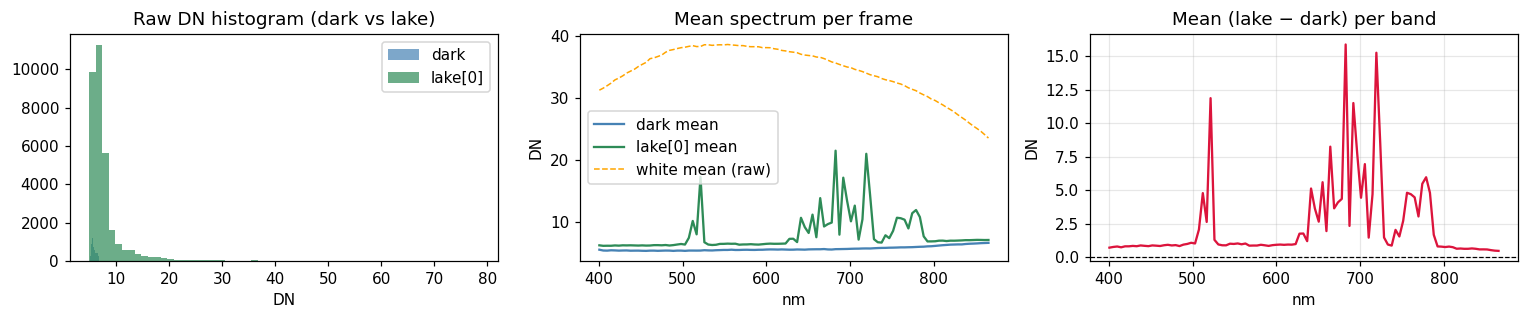

In [13]:
# --- DEBUG A: raw lake DN vs dark ---
sample_lake_frame, _ = load_raw_frame(LAKE_PATHS[0], cfg)
sample_lake_cube     = bin_to_cube(sample_lake_frame, cfg)

print(f"Dark  cube  — min={dark_cube.min():.1f}  median={np.median(dark_cube):.1f}  max={dark_cube.max():.1f}")
print(f"Lake  cube  — min={sample_lake_cube.min():.1f}  median={np.median(sample_lake_cube):.1f}  max={sample_lake_cube.max():.1f}")
print(f"(lake - dark) — min={( sample_lake_cube-dark_cube).min():.1f}  median={np.median(sample_lake_cube-dark_cube):.1f}  max={(sample_lake_cube-dark_cube).max():.1f}")
frac_below_dark = np.mean(sample_lake_cube < dark_cube)
print(f"Fraction of lake pixels below the dark level: {100*frac_below_dark:.1f}%  <-- should be ~0%; if high, calibration will be negative")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].hist(dark_cube.ravel(),        bins=60, color='steelblue',  alpha=0.7, label='dark')
axes[0].hist(sample_lake_cube.ravel(), bins=60, color='seagreen',   alpha=0.7, label='lake[0]')
axes[0].set_title('Raw DN histogram (dark vs lake)'); axes[0].set_xlabel('DN'); axes[0].legend()

axes[1].plot(wls, np.mean(dark_cube, axis=1),        label='dark mean',  color='steelblue')
axes[1].plot(wls, np.mean(sample_lake_cube, axis=1), label='lake[0] mean', color='seagreen')
axes[1].plot(wls, np.mean(white_cube, axis=1),       label='white mean (raw)', color='orange', lw=1, ls='--')
axes[1].set_title('Mean spectrum per frame'); axes[1].set_xlabel('nm'); axes[1].set_ylabel('DN'); axes[1].legend()

diff = sample_lake_cube - dark_cube
axes[2].plot(wls, np.mean(diff, axis=1), color='crimson')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_title('Mean (lake − dark) per band'); axes[2].set_xlabel('nm'); axes[2].set_ylabel('DN')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## DEBUG A2 — Dark frame quality check + workaround
99.4 % of lake pixels are below the dark level, so the dark frame is too bright.
This cell checks *which bands* are worst and estimates a replacement dark from the data itself.

## 6. White-reference **saturation check** → set SAT_BIAS

In [14]:
# effective data range (10-bit data often lives in a 16-bit container)
wmax = white_frame.max()
cap = next(c for c in (255, 1023, 4095, 65535) if wmax <= c)
sat_frac = 100 * (white_frame >= cap).mean()
print(f'White max DN = {wmax:.0f}  -> effective cap {cap} ; {sat_frac:.2f}% of pixels at/above cap')

if sat_frac < 1.0:
    SAT_BIAS = 1.0
    print('White reference is NOT saturated -> reflectance is quantitative (SAT_BIAS = 1.0).')
else:
    SAT_BIAS = 3.5
    print(f'WARNING: white reference is {sat_frac:.0f}% saturated. Absolute reflectance is unreliable;')
    print(f'         using SAT_BIAS = {SAT_BIAS} as a stop-gap. Re-shoot the white panel at lower')
    print('         exposure/gain for trustworthy values. Band RATIOS (NDCI) remain valid.')

White max DN = 81  -> effective cap 255 ; 0.00% of pixels at/above cap
White reference is NOT saturated -> reflectance is quantitative (SAT_BIAS = 1.0).


## 7. Calibrate to reflectance

In [15]:
from tqdm import tqdm
PANEL_R = 0.99

# White ref was shot at GAIN_WHITE; dark and lake frames at GAIN_LAKE.
# Scale white DN back to the lake gain so the calibration ratio is correct.
GAIN_WHITE = 30
GAIN_LAKE  = 10
white_cube_cal = (white_cube - dark_cube) * (GAIN_LAKE / GAIN_WHITE) + dark_cube
print(f'Gain-corrected white cube range {white_cube_cal.min():.1f}-{white_cube_cal.max():.1f}')

OFF_PANEL_THRESHOLD = white_cube_cal.mean() * 0.4

def calibrate(target_cube):
    panel = white_cube_cal.mean(axis=0) > OFF_PANEL_THRESHOLD
    denom = np.where(np.abs(white_cube_cal - dark_cube) < 0.5, np.nan, white_cube_cal - dark_cube)
    R = (target_cube - dark_cube) / denom * PANEL_R / SAT_BIAS
    R[:, ~panel] = np.nan
    return R, panel

results = {}
for p in tqdm(LAKE_PATHS):
    frame, _ = load_raw_frame(p, cfg)
    cube = bin_to_cube(frame, cfg)
    R, panel = calibrate(cube)
    results[Path(p).name] = dict(cube=cube, reflectance=R, panel_mask=panel)
print(f'calibrated {len(results)} frames; median R = {np.nanmedian([np.nanmedian(r["reflectance"]) for r in results.values()]):.4f}')

Gain-corrected white cube range 5.1-29.7


100%|██████████| 4/4 [00:00<00:00, 45.60it/s]

calibrated 4 frames; median R = 0.1141


## DEBUG B — Calibration denominator & panel mask
Checks that (white_cal − dark) is large and positive, and that the panel mask is reasonable.

(white_cal − dark) range: min=0.00  median=9.17  max=24.03
  negative-denom fraction: 0.0%  <-- non-zero means white < dark after gain correction (bad)

Panel mask: 284 / 320 spatial pixels kept  (threshold = 6.1)

Sample reflectance (frame 0):
  min=-0.469  median=0.114  max=3.992
  fraction negative: 2.5%
  fraction NaN:      11.9%


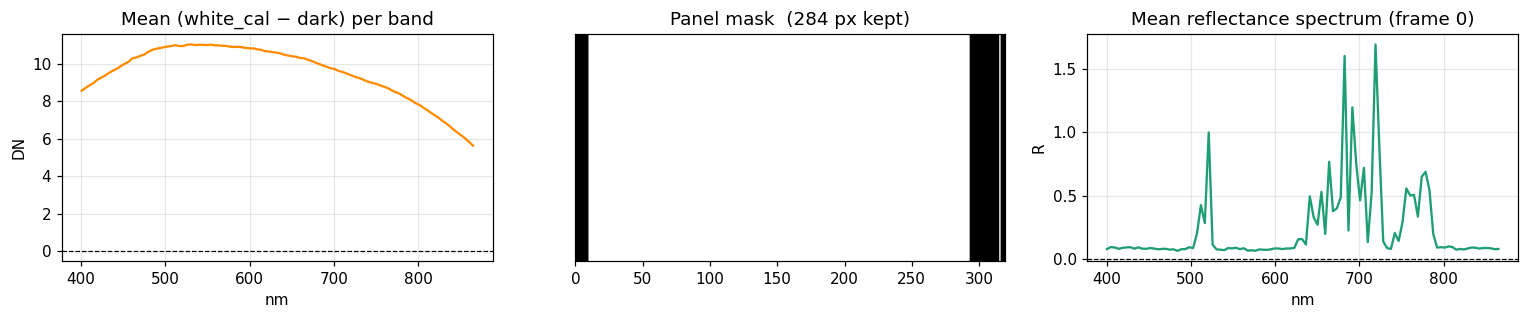

In [16]:
# --- DEBUG B: calibration denominator & panel mask ---
denom = white_cube_cal - dark_cube   # shape: (n_bands, n_spatial)
print(f"(white_cal − dark) range: min={denom.min():.2f}  median={np.median(denom):.2f}  max={denom.max():.2f}")
print(f"  negative-denom fraction: {100*np.mean(denom < 0):.1f}%  <-- non-zero means white < dark after gain correction (bad)")

panel_mask_1d = white_cube_cal.mean(axis=0) > OFF_PANEL_THRESHOLD
print(f"\nPanel mask: {panel_mask_1d.sum()} / {len(panel_mask_1d)} spatial pixels kept  "
      f"(threshold = {OFF_PANEL_THRESHOLD:.1f})")

# show sample reflectance from the already-computed first result
first_name = list(results.keys())[0]
R_sample = results[first_name]['reflectance']
print(f"\nSample reflectance (frame 0):")
print(f"  min={np.nanmin(R_sample):.3f}  median={np.nanmedian(R_sample):.3f}  max={np.nanmax(R_sample):.3f}")
print(f"  fraction negative: {100*np.mean(R_sample[np.isfinite(R_sample)] < 0):.1f}%")
print(f"  fraction NaN:      {100*np.mean(np.isnan(R_sample)):.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

axes[0].plot(wls, np.nanmean(denom, axis=1), color='darkorange')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_title('Mean (white_cal − dark) per band'); axes[0].set_xlabel('nm'); axes[0].set_ylabel('DN')
axes[0].grid(alpha=0.3)

axes[1].imshow(panel_mask_1d[np.newaxis, :], aspect='auto', cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Panel mask  ({panel_mask_1d.sum()} px kept)'); axes[1].set_yticks([])

axes[2].plot(wls, np.nanmean(R_sample, axis=1), color='#1D9E75')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_title('Mean reflectance spectrum (frame 0)'); axes[2].set_xlabel('nm'); axes[2].set_ylabel('R')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8. Per-frame preview (capped) + mean spectrum

4 frames; previewing first 3.


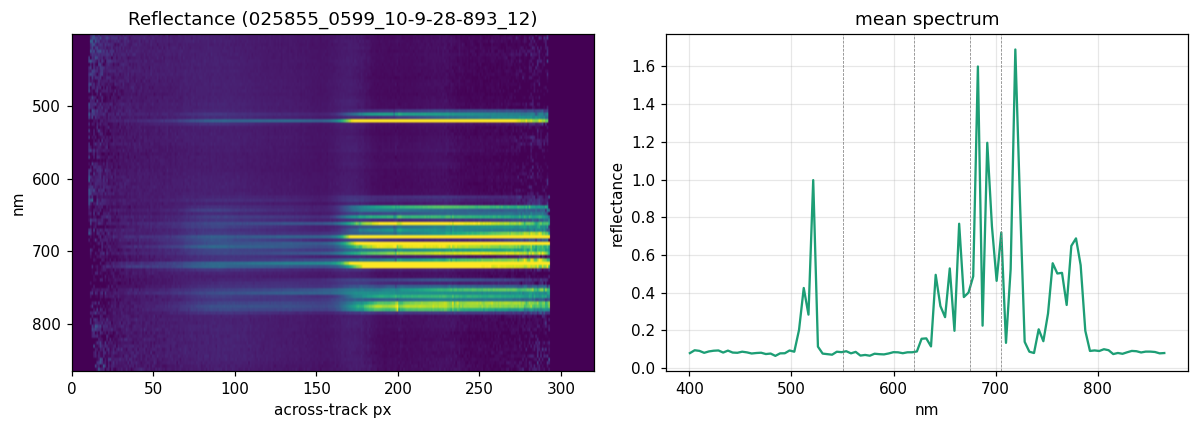

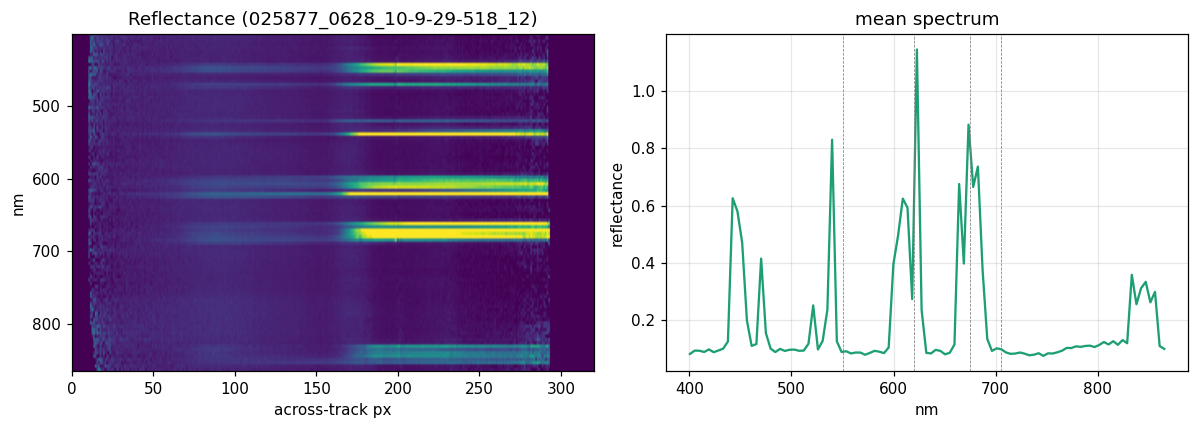

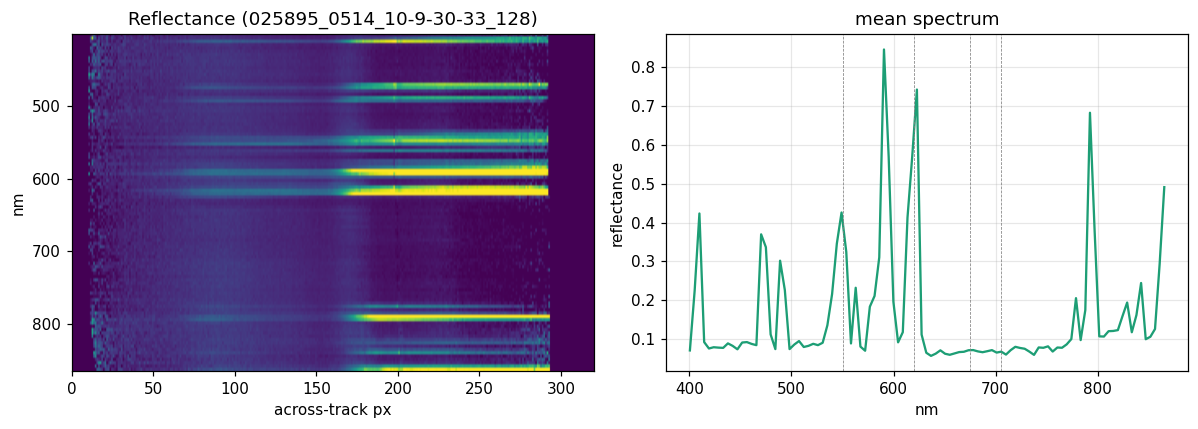

In [17]:
MAX_PREVIEW = 3
prev = list(results.items())[:MAX_PREVIEW]
if len(results) > MAX_PREVIEW:
    print(f'{len(results)} frames; previewing first {MAX_PREVIEW}.')
for name, r in prev:
    R = r['reflectance']
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].imshow(np.clip(np.nan_to_num(R), 0, np.nanpercentile(R, 98)), aspect='auto', cmap='viridis',
                 extent=[0, cfg['n_spatial'], wls[-1], wls[0]])
    ax[0].set_title(f'Reflectance ({name[:26]})'); ax[0].set_xlabel('across-track px'); ax[0].set_ylabel('nm')
    ax[1].plot(wls, np.nanmean(R, axis=1), color='#1D9E75')
    for nm, lab in [(550,'green'),(620,'PC'),(675,'chl-a'),(705,'red edge')]:
        ax[1].axvline(nm, color='gray', ls='--', lw=0.5)
    ax[1].set_title('mean spectrum'); ax[1].set_xlabel('nm'); ax[1].set_ylabel('reflectance'); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 9. Water-quality indices (NDCI, red-edge, chl-a) — capped preview\nBand ratios are robust to absolute calibration error.

C:\Users\daven\AppData\Local\Temp\ipykernel_27672\1541384929.py:8: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(R705 / R620, color='#A32D2D'); ax[1].set_title('R705/R620 (phycocyanin)'); ax[1].grid(alpha=0.3)


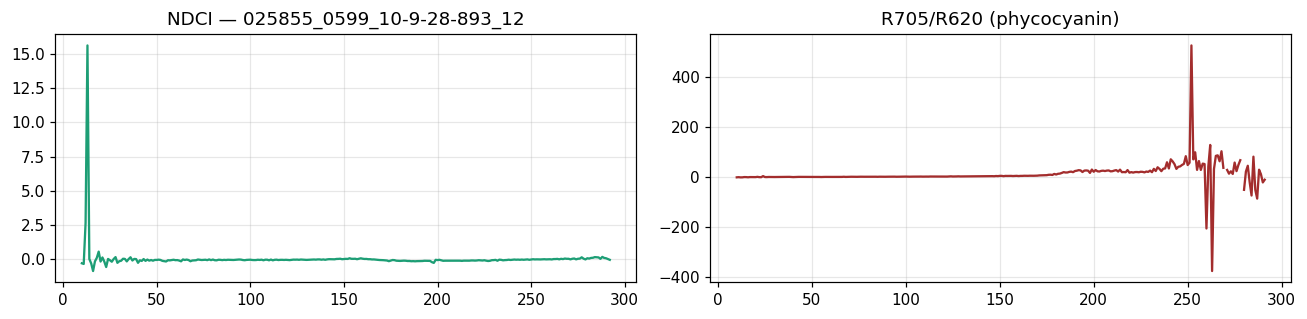

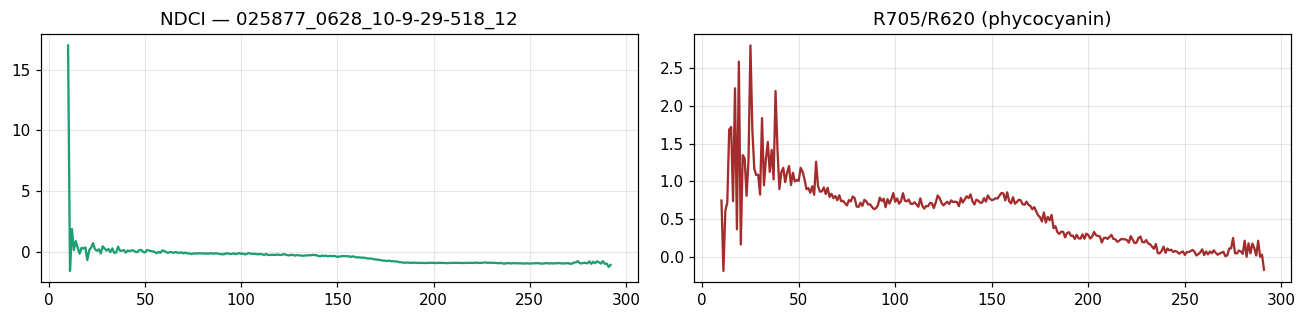

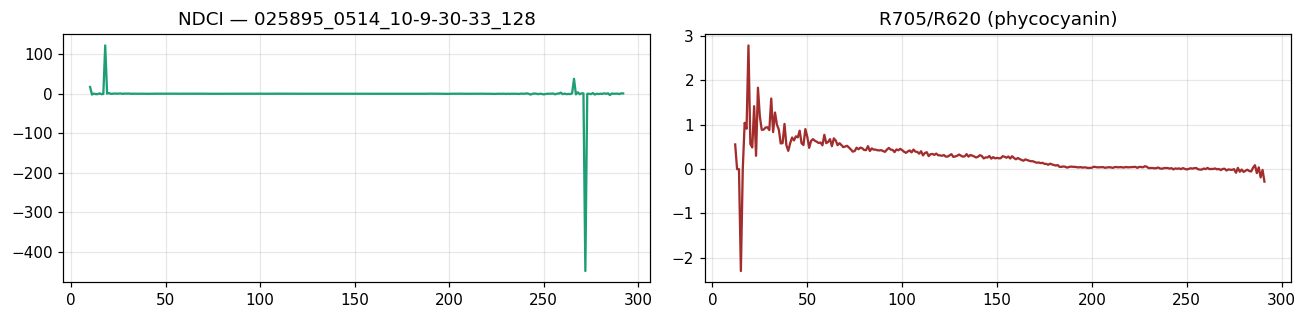

In [18]:
def band(R, nm): return R[np.argmin(np.abs(wls - nm)), :]
for name, r in prev:
    R = r['reflectance']
    R705, R665, R620 = band(R,705), band(R,665), band(R,620)
    ndci = (R705 - R665) / (R705 + R665)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(ndci, color='#1D9E75'); ax[0].set_title(f'NDCI — {name[:26]}'); ax[0].grid(alpha=0.3)
    ax[1].plot(R705 / R620, color='#A32D2D'); ax[1].set_title('R705/R620 (phycocyanin)'); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## DEBUG C — NDCI band-level inspection
Why is NDCI ≈ 0 with low std? Check R705 and R665 values directly.

R665  — mean=0.3966  std=0.5216  median=0.1253
R705  — mean=0.3107  std=0.3797  median=0.1461
NDCI  — mean=-0.2180  std=13.9244  median=-0.0062  [range -448.986..122.333]

If R665 ≈ R705 ≈ some negative number, NDCI → 0 as a pure math artefact — not a real signal.
Valid NDCI requires R665 and R705 to both be positive (real reflectance above dark).


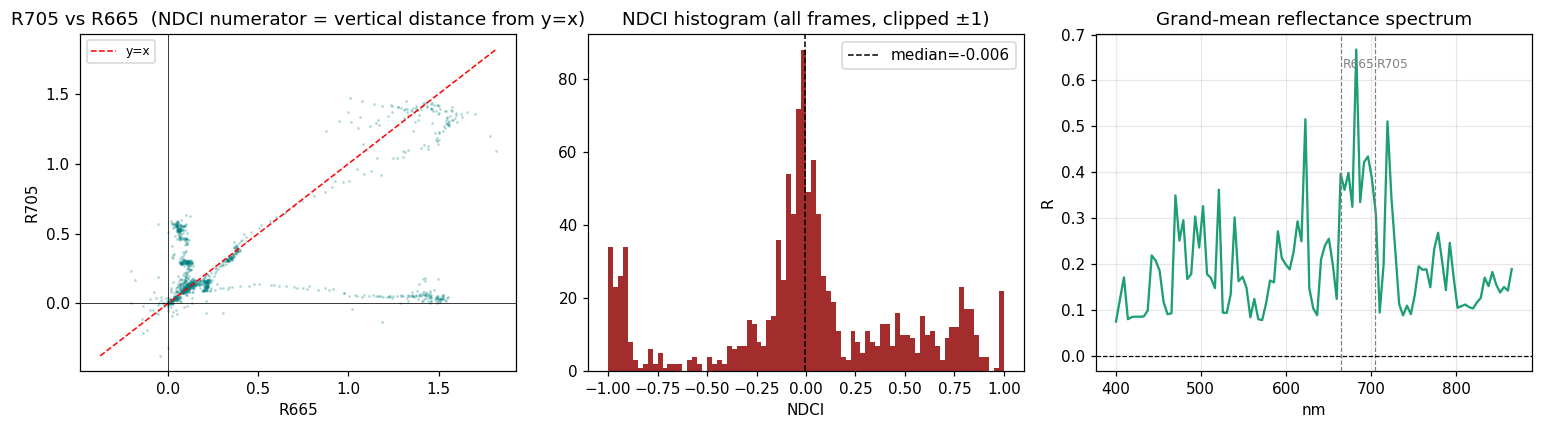

In [19]:
# --- DEBUG C: NDCI band-level inspection ---
# Collect R665, R705 across all frames (finite pixels only)
r665_all, r705_all, ndci_all = [], [], []
for r in results.values():
    R = r['reflectance']
    r6 = band(R, 665); r7 = band(R, 705)
    nd = (r7 - r6) / (r7 + r6)
    fin = np.isfinite(r6) & np.isfinite(r7) & np.isfinite(nd)
    r665_all.append(r6[fin]); r705_all.append(r7[fin]); ndci_all.append(nd[fin])

r665_all  = np.concatenate(r665_all)
r705_all  = np.concatenate(r705_all)
ndci_all  = np.concatenate(ndci_all)

print("R665  — mean={:.4f}  std={:.4f}  median={:.4f}".format(r665_all.mean(), r665_all.std(), np.median(r665_all)))
print("R705  — mean={:.4f}  std={:.4f}  median={:.4f}".format(r705_all.mean(), r705_all.std(), np.median(r705_all)))
print("NDCI  — mean={:.4f}  std={:.4f}  median={:.4f}  [range {:.3f}..{:.3f}]".format(
      ndci_all.mean(), ndci_all.std(), np.median(ndci_all), ndci_all.min(), ndci_all.max()))
print()
print("If R665 ≈ R705 ≈ some negative number, NDCI → 0 as a pure math artefact — not a real signal.")
print("Valid NDCI requires R665 and R705 to both be positive (real reflectance above dark).")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# scatter R665 vs R705 — expect points along the y=x diagonal if they are equal
sub = slice(None, 5000)   # subsample for speed
axes[0].scatter(r665_all[sub], r705_all[sub], s=1, alpha=0.2, color='teal')
lims = [min(r665_all.min(), r705_all.min()), max(r665_all.max(), r705_all.max())]
axes[0].plot(lims, lims, 'r--', lw=1, label='y=x')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_xlabel('R665'); axes[0].set_ylabel('R705')
axes[0].set_title('R705 vs R665  (NDCI numerator = vertical distance from y=x)')
axes[0].legend(fontsize=8)

# histogram of NDCI
axes[1].hist(np.clip(ndci_all, -1, 1), bins=80, color='#A32D2D', edgecolor='none')
axes[1].axvline(np.median(ndci_all), color='k', lw=1, ls='--', label=f'median={np.median(ndci_all):.3f}')
axes[1].set_title('NDCI histogram (all frames, clipped ±1)'); axes[1].set_xlabel('NDCI'); axes[1].legend()

# per-band mean reflectance across all frames (to see spectral shape)
all_R = np.stack([r['reflectance'] for r in results.values()])  # (N, bands, spatial)
mean_spec = np.nanmean(all_R.reshape(all_R.shape[0], all_R.shape[1], -1), axis=(0, 2))
axes[2].plot(wls, mean_spec, color='#1D9E75')
for nm, lab in [(665, 'R665'), (705, 'R705')]:
    axes[2].axvline(nm, color='gray', ls='--', lw=0.8)
    axes[2].text(nm+2, axes[2].get_ylim()[1]*0.9, lab, fontsize=8, color='gray')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_title('Grand-mean reflectance spectrum'); axes[2].set_xlabel('nm'); axes[2].set_ylabel('R')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Save combined results (one `.npz`)

In [20]:
OUT_DIR = 'bayspec_results'
os.makedirs(OUT_DIR, exist_ok=True)
names = sorted(results.keys())
reflectance = np.stack([results[n]['reflectance'] for n in names])
out = os.path.join(OUT_DIR, 'silver_combined_processed.npz')
np.savez_compressed(out, frame_names=np.array(names), reflectance=reflectance,
                    wavelengths=wls, dark_cube=dark_cube, white_cube=white_cube,
                    bits=BITS, sat_bias=SAT_BIAS, panel_reflectance=PANEL_R)

## 11. *(Optional)* Georeferenced glint-free mosaic for QGIS

Needs a **GPS flight-log CSV** (decoded DJI log: columns `OSD.latitude`, `OSD.longitude`,
`OSD.yaw [360]`, `CUSTOM.updateTime [local]`). Frame timestamps (from filenames) are matched
to the GPS track; each scan line is placed by heading + an estimated swath, sun-glint is
removed (high-NIR + specular outliers), gaps are filled and the result smoothed, then written
as true-color + NDCI GeoTIFFs in UTM. **Set `UTM_EPSG` for your site** (NJ = 32618).

C:\Users\daven\AppData\Local\Temp\ipykernel_27672\689863148.py:60: RuntimeWarning: Mean of empty slice
  nir = REFL[:, :, i800]; vis = np.nanmean(REFL[:, :, [iR, iG, iB]], axis=2)


glint mask removed 60.0% of pixels


C:\Users\daven\AppData\Local\Temp\ipykernel_27672\689863148.py:112: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(g3, 0, keepdims=True); g3 = np.clip(mean + (g3-mean)*1.5, 0, 1)


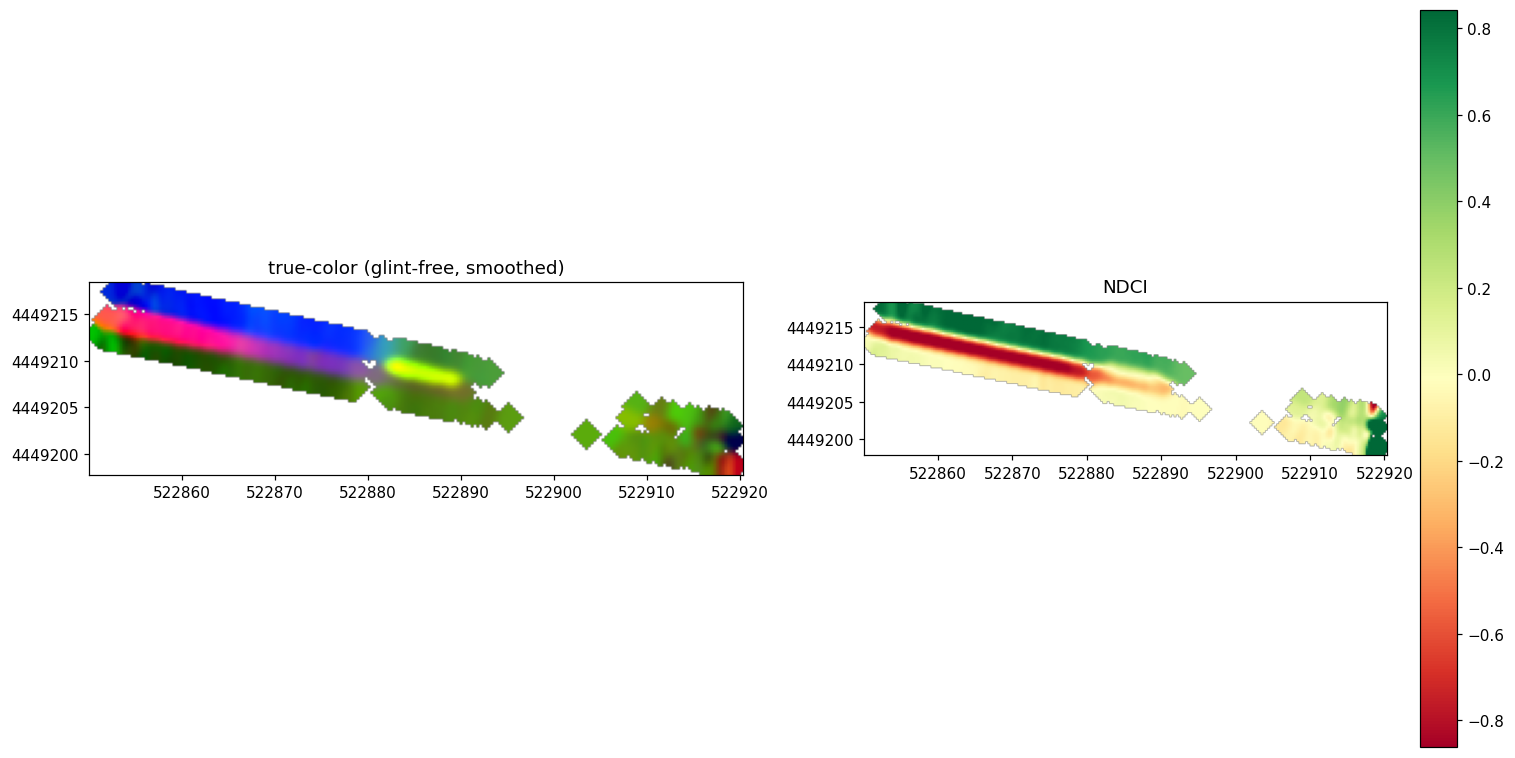

wrote bayspec_results\silver_truecolor_utm.tif
wrote bayspec_results\silver_ndci_utm.tif


In [21]:
import rasterio
from rasterio.transform import from_origin
from rasterio.crs import CRS
from rasterio.warp import transform as warp_transform
from scipy.ndimage import gaussian_filter, distance_transform_edt, binary_dilation

# ---- config ----
UTM_EPSG   = 32618        # UTM zone for your site (NJ = 18N = 32618)
SWATH_M    = 80.0         # across-track ground swath (m) ~ altitude * FOV; tune vs a basemap
RES_M      = 0.30
RGB_NM     = (620, 550, 470)
GLINT_NIR_PCTL = 55       # keep darker-NIR (water) pixels below this percentile
SMOOTH_SIG = 1.5
FILL_RAD   = 5

FLIGHTLOG = pick('Select the GPS flight-log CSV (Cancel to skip georeferencing)',
                 filetypes=[('CSV', '*.csv'), ('All files', '*.*')])


if not FLIGHTLOG:
    print('No flight log — skipping georeferencing. (Combined .npz already saved.)')
else:
    def sod_ampm(t):
        t = t.strip()
        parts = t.split(':')
        if len(parts) == 2:          # DJI MM:SS.f format (no hour)
            return int(parts[0]) * 60 + float(parts[1])
        d = datetime.datetime.strptime(t, '%I:%M:%S.%f %p')
        return d.hour*3600 + d.minute*60 + d.second + d.microsecond/1e6
    def sod_fname(n):
        q = Path(n).name.split('_')[2].split('-'); h, m, s_, ms = (int(x) for x in q)
        return h*3600 + m*60 + s_ + ms/1000.0
    gt, glat, glon, gyaw = [], [], [], []
    with open(FLIGHTLOG, encoding='utf-8-sig') as f:
        for row in csv.DictReader(f):
            try:
                gt.append(sod_ampm(row['CUSTOM.updateTime [local]']))
                glat.append(float(row['OSD.latitude'])); glon.append(float(row['OSD.longitude']))
                gyaw.append(float(row['OSD.yaw [360]']))
            except Exception: pass
    gt = np.array(gt); o = np.argsort(gt)
    gt, glat, glon = gt[o], np.array(glat)[o], np.array(glon)[o]; gyaw = np.deg2rad(np.array(gyaw)[o])
    # MM:SS.f has no hour — recover it from the frame filenames
    if gt.max() < 3600:
        frame_sod = sod_fname(names[0])
        hour_offset = (int(frame_sod) // 3600) * 3600
        gt = gt + hour_offset

    names = sorted(results.keys())
    ns = cfg['n_spatial']
    iR, iG, iB = [np.argmin(np.abs(wls - x)) for x in RGB_NM]
    i665, i705, i800 = [np.argmin(np.abs(wls - x)) for x in (665, 705, 800)]
    REFL = np.stack([results[n]['reflectance'].T for n in names])   # (N, ns, nbands)

    # inter-frame normalization (one gain per frame -> smooth between frames)
    fb = np.nanmedian(REFL.reshape(len(names), -1), axis=1)
    REFL = REFL * np.where(np.abs(fb) > 1e-6, np.nanmedian(fb) / fb, np.nan)[:, None, None]

    # glint / land removal: water is dark in NIR; drop bright specular outliers
    nir = REFL[:, :, i800]; vis = np.nanmean(REFL[:, :, [iR, iG, iB]], axis=2)
    fin = np.isfinite(nir) & np.isfinite(vis)
    nthr = np.nanpercentile(nir[fin], GLINT_NIR_PCTL)
    med = np.nanmedian(vis[fin]); mad = np.nanmedian(np.abs(vis[fin] - med))
    glint = (~fin) | (nir > nthr) | (vis > med + 3*1.4826*mad)
    REFL[np.broadcast_to(glint[:, :, None], REFL.shape)] = np.nan
    print(f'glint mask removed {100*glint.mean():.1f}% of pixels')

    # georeference each scan line
    ft = np.array([sod_fname(n) for n in names])
    flat = np.interp(ft, gt, glat); flon = np.interp(ft, gt, glon)
    fyaw = np.arctan2(np.interp(ft, gt, np.sin(gyaw)), np.interp(ft, gt, np.cos(gyaw)))
    cE, cN = warp_transform(CRS.from_epsg(4326), CRS.from_epsg(UTM_EPSG), list(flon), list(flat))
    cE, cN = np.array(cE), np.array(cN)
    off = (np.arange(ns) - (ns-1)/2.0) * (SWATH_M / ns)
    bear = fyaw[:, None] + np.pi/2
    sE = cE[:, None] + off[None, :]*np.sin(bear); sN = cN[:, None] + off[None, :]*np.cos(bear)

    valid = np.isfinite(REFL).any(2) & np.isfinite(sE) & np.isfinite(sN)
    xmin, xmax = sE[valid].min()-1, sE[valid].max()+1
    ymin, ymax = sN[valid].min()-1, sN[valid].max()+1
    ncol = int(np.ceil((xmax-xmin)/RES_M)); nrow = int(np.ceil((ymax-ymin)/RES_M))
    col = np.clip(((sE-xmin)/RES_M).astype(int), 0, ncol-1)
    rowi = np.clip(((ymax-sN)/RES_M).astype(int), 0, nrow-1)
    tr = from_origin(xmin, ymax, RES_M, RES_M)

    def grid_layers(v):
        L = v.shape[2]; out = np.zeros((L, nrow, ncol)); cnt = np.zeros((L, nrow, ncol))
        rr = np.broadcast_to(rowi[:, :, None], v.shape); cc = np.broadcast_to(col[:, :, None], v.shape)
        ok = np.isfinite(v)
        for l in range(L):
            m = ok[:, :, l]
            np.add.at(out[l], (rr[:, :, l][m], cc[:, :, l][m]), v[:, :, l][m])
            np.add.at(cnt[l], (rr[:, :, l][m], cc[:, :, l][m]), 1)
        with np.errstate(invalid='ignore'):
            return np.where(cnt > 0, out/cnt, np.nan)

    def fill_smooth(layer):
        m = np.isfinite(layer)
        idx = distance_transform_edt(~m, return_distances=False, return_indices=True)
        sm = gaussian_filter(layer[tuple(idx)], SMOOTH_SIG)
        foot = binary_dilation(m, iterations=FILL_RAD)
        return np.where(foot, sm, np.nan), foot

    # true-color RGB
    rgb = grid_layers(REFL[:, :, [iR, iG, iB]])
    chans, foot = [], None
    for k in range(3):
        c, foot = fill_smooth(rgb[k]); chans.append(c)
    g3 = np.stack(chans)
    cm = np.nanmean(g3.reshape(3, -1), 1); g3 = g3 * (np.nanmean(cm)/(cm[:, None, None]+1e-9))
    lo, hi = np.nanpercentile(g3, [2, 98]); g3 = np.clip((g3-lo)/(hi-lo+1e-9), 0, 1)**0.8
    mean = np.nanmean(g3, 0, keepdims=True); g3 = np.clip(mean + (g3-mean)*1.5, 0, 1)
    rgb8 = np.where(np.isfinite(g3), g3*255, 0).astype(np.uint8)
    alpha = (foot & np.isfinite(g3).all(0)).astype(np.uint8)*255
    tc = os.path.join(OUT_DIR, 'silver_truecolor_utm.tif')
    with rasterio.open(tc, 'w', driver='GTiff', height=nrow, width=ncol, count=4, dtype='uint8',
                       crs=CRS.from_epsg(UTM_EPSG), transform=tr, photometric='RGB', compress='deflate') as ds:
        for b in range(3): ds.write(rgb8[b], b+1)
        ds.write(alpha, 4)

    # NDCI
    R665 = REFL[:, :, i665]; R705 = REFL[:, :, i705]
    nd = grid_layers(((R705-R665)/(R705+R665))[:, :, None])[0]
    nd, ndf = fill_smooth(nd); nd = np.where(ndf, nd, np.nan).astype('float32')
    ndp = os.path.join(OUT_DIR, 'silver_ndci_utm.tif')
    with rasterio.open(ndp, 'w', driver='GTiff', height=nrow, width=ncol, count=1, dtype='float32',
                       crs=CRS.from_epsg(UTM_EPSG), transform=tr, nodata=float('nan'), compress='deflate') as ds:
        ds.write(nd, 1)

    ext = [xmin, xmax, ymin, ymax]
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(np.dstack([rgb8[0], rgb8[1], rgb8[2], alpha]), extent=ext, origin='upper')
    ax[0].set_title('true-color (glint-free, smoothed)'); ax[0].ticklabel_format(useOffset=False, style='plain')
    im = ax[1].imshow(nd, extent=ext, origin='upper', cmap='RdYlGn',
                      vmin=np.nanpercentile(nd, 5), vmax=np.nanpercentile(nd, 95))
    ax[1].set_title('NDCI'); plt.colorbar(im, ax=ax[1]); ax[1].ticklabel_format(useOffset=False, style='plain')
    plt.tight_layout(); plt.show()
    print(f'wrote {tc}\nwrote {ndp}')

## Notes (for sharing / re-running)

- **Bit depth** is auto-detected from raw file size — works for the old 8-bit *and* the
  new 10/16-bit captures with no change.
- **SAT_BIAS** is set automatically: `1.0` when the white reference is unsaturated
  (quantitative reflectance), otherwise a flagged stop-gap.
- **Geometry:** each raw frame is one across-track scan line (`n_bands × n_spatial`);
  the 2-D map only appears after stacking frames (Section 11).
- **Georeferencing** needs a decoded DJI GPS CSV and the correct `UTM_EPSG` for the site.
  `SWATH_M` is an estimate — tune it against a basemap in QGIS.
- Outputs are written to `./bayspec_results/`.
